# Uso basico de XAI-metrics con configuracion YAML

Este cuaderno muestra un ejemplo sencillo de evaluación con `XAIMetrics` usando el archivo `config_example.yaml`.

La configurajción define las rutas de los datos, el modelo y las atribcuiones, además de las métricas y sus parámetros.

## 1. Preparar el entorno

El paquete debe estar instalado en modo editable con `pip install -e .`.

La siguiente celda configura las rutas necesarias para ejecutar el cuaderno desde la raíz del proyecto o desde `examples/`.

In [10]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "examples":
    PROJECT_ROOT = ROOT.parent
    EXAMPLES_DIR = ROOT
else:
    PROJECT_ROOT = ROOT
    EXAMPLES_DIR = ROOT / "examples"

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(EXAMPLES_DIR)

from xai_metrics.runner import run_evaluation


## 2. Revisar la configuracion

El archivo `config_example.yaml` utiliza rutas relativas a `examples/`.

Con esa configuracion, la evaluacion descubre automaticamente el dataset `hydraulic`, el modelo `IForest`, las atribuciones disponibles y las métricas que se deben ejecutar.

In [11]:
CONFIG_PATH = Path("config_example.yaml")

with CONFIG_PATH.open("r", encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

config

{'context': {'device': 'cpu',
  'datasets_dir': 'datasets',
  'models_dir': 'models',
  'attributions_dir': 'attributions'},
 'metrics': [{'name': 'Complexity', 'params': {'normalise': True}},
  {'name': 'Sparseness', 'params': {'normalise': True}},
  {'name': 'Faithfulness', 'params': {'base_strategy': 'mean'}},
  {'name': 'LocalLipschitzEstimate',
   'params': {'nr_samples': 200, 'normalise': True}}],
 'explainers': [{'name': 'LIME',
   'params': {'mode': 'classification',
    'random_state': 42,
    'num_samples': 5000,
    'labels': [1],
    'distance_metric': 'euclidean'}},
  {'name': 'SHAP',
   'params': {'mode': 'classification',
    'algorithm': 'auto',
    'max_background_samples': 100,
    'output_index': 1,
    'abs': True,
    'random_state': 42}},
  {'name': 'BreakDown',
   'params': {'mode': 'classification',
    'output_index': 1,
    'abs': True,
    'random_state': 42}},
  {'name': 'MAPLE',
   'params': {'mode': 'classification',
    'output_index': 1,
    'fe_type': '

## 3. Definir funciones de explicacion

Algunas métricas, como `LocalLipschitzEstimate`, necesitan generar nuevas explicaciones sobre muestras perturbadas.

Por ello, se definen funciones para calcular atribuciones mediante **LIME** y **SHAP**. Estas funciones reciben el modelo y las observaciones, y devuelven una matriz de atribuciones.

In [12]:
from xai_metrics.base import ExplainerContext, build_explainers_from_config
from xai_metrics.config.config_controller import ConfigController, default_model_loader

import xai_metrics.explainers as explainers_pkg
from xai_metrics.explainers import autodiscover_explainers

autodiscover_explainers(explainers_pkg)

config_controller = ConfigController(
    config=CONFIG_PATH,
    model_loader=default_model_loader,
)

X_background = pd.read_csv("datasets/MetroPT3/X_background.csv", index_col=0)
y_background = pd.read_csv("datasets/MetroPT3/y_background.csv", index_col=0).iloc[:, 0]

explainer_context = ExplainerContext(
    X_background=X_background,
    y_background=y_background,
)

explainers = build_explainers_from_config(
    config_controller.get_explainers_config(),
    explainer_context,
)

explain_funcs = {
    explainer.NAME: explainer.as_explain_func()
    for explainer in explainers
}

explain_funcs

{'LIME': <bound method LIMEExplainer.explain of <xai_metrics.explainers.lime.LIMEExplainer object at 0x70241cdaa2c0>>,
 'SHAP': <bound method SHAPExplainer.explain of <xai_metrics.explainers.shap.SHAPExplainer object at 0x70241cda9ba0>>,
 'BreakDown': <bound method BreakDownExplainer.explain of <xai_metrics.explainers.breakdown.BreakDownExplainer object at 0x70241cda82b0>>,
 'MAPLE': <bound method MAPLEExplainer.explain of <xai_metrics.explainers.maple.MAPLEExplainer object at 0x70241cda8510>>}

## 4. Generar y guardar las atribuciones

Se generan las atribuciones de **LIME**, **SHAP**, **BreakDown** y **MAPLE** utilizando los parámetros definidos en `config_example.yaml`.

Los archivos CSV se guardan siguiendo la estructura:

`attributions/<dataset>/<modelo>/<método>/`

In [13]:
from xai_metrics.runner import run_explanation

ATTRIBUTIONS_DIR = Path(config["context"]["attributions_dir"])

explanation = run_explanation(
    config=CONFIG_PATH,
    model_loader=default_model_loader,
    attribution_output_dir=ATTRIBUTIONS_DIR,
)

attribution_paths = explanation["attribution_paths"]

display(
    pd.DataFrame(
        attribution_paths.items(),
        columns=["Método XAI", "Archivo de atribuciones"],
    )
)


Running XAI explanations
  Dataset : MetroPT3
  Model   : IForest
  [explainer] Running LIME...
  [explainer] Finished LIME
  [explainer] Running SHAP...
  [explainer] Finished SHAP
  [explainer] Running BreakDown...
  [explainer] Finished BreakDown
  [explainer] Running MAPLE...
  [explainer] Finished MAPLE


,Método XAI,Archivo de atribuciones
0,LIME,attributions/MetroPT3/IForest/LIME/MetroPT3_IF...
1,SHAP,attributions/MetroPT3/IForest/SHAP/MetroPT3_IF...
2,BreakDown,attributions/MetroPT3/IForest/BreakDown/MetroP...
3,MAPLE,attributions/MetroPT3/IForest/MAPLE/MetroPT3_I...


## 5. Ejecutar la evaluacion

La función `run_evaluation` recibe la configuración, las funciones de explicación y el directorio de salida.

Durante la ejecución, `XAIMetrics` carga los recursos, construye los contextos, ejecuta las métricas y genera los informes.

Los resultados se guardan en `results/reports`. Para no escribir archivos en disco, puede utilizarse:

```python
report_output_dir=None
```

In [14]:
REPORTS_DIR = Path("results/reports")

evaluation = run_evaluation(
    config=CONFIG_PATH,
    report_output_dir=REPORTS_DIR,
    explain_funcs=explain_funcs,
)


Running XAI evaluation
  Dataset    : MetroPT3
  Model      : IForest
  XAI method : BreakDown
  [metric] Running Complexity ({'normalise': True})...
  [metric] Finished Complexity ({'normalise': True})
  [metric] Running Sparseness ({'normalise': True})...
  [metric] Finished Sparseness ({'normalise': True})
  [metric] Running Faithfulness ({'base_strategy': 'mean'})...
  [metric] Finished Faithfulness ({'base_strategy': 'mean'})
  [metric] Running LocalLipschitzEstimate ({'nr_samples': 200, 'normalise': True})...
  [metric] Finished LocalLipschitzEstimate ({'nr_samples': 200, 'normalise': True})

Running XAI evaluation
  Dataset    : MetroPT3
  Model      : IForest
  XAI method : LIME
  [metric] Running Complexity ({'normalise': True})...
  [metric] Finished Complexity ({'normalise': True})
  [metric] Running Sparseness ({'normalise': True})...
  [metric] Finished Sparseness ({'normalise': True})
  [metric] Running Faithfulness ({'base_strategy': 'mean'})...
  [metric] Finished Fait

ExactExplainer explainer: 43it [00:15,  1.01it/s]                        
ExactExplainer explainer: 43it [00:15,  1.04s/it]                        
ExactExplainer explainer: 43it [00:15,  1.03it/s]                        
ExactExplainer explainer: 43it [00:15,  1.02it/s]                        
ExactExplainer explainer: 43it [00:15,  1.01it/s]                        
ExactExplainer explainer: 43it [00:15,  1.01it/s]                        
ExactExplainer explainer: 43it [00:15,  1.01it/s]                        
ExactExplainer explainer: 43it [00:15,  1.02it/s]                        
ExactExplainer explainer: 43it [00:15,  1.03it/s]                        
ExactExplainer explainer: 43it [00:15,  1.02s/it]                        
ExactExplainer explainer: 43it [00:16,  1.01s/it]                        
ExactExplainer explainer: 43it [00:15,  1.04s/it]                        
ExactExplainer explainer: 43it [00:16,  1.03it/s]                        
ExactExplainer explainer: 43it [00:15,

  [metric] Finished LocalLipschitzEstimate ({'nr_samples': 200, 'normalise': True})


In [15]:
evaluation

{'contexts': [{'metadata': {'dataset_name': 'MetroPT3',
    'model_name': 'IForest',
    'xai_method_name': 'BreakDown'},
   'observations': ['2020-07-08 17:30:00',
    '2020-07-08 18:30:00',
    '2020-07-15 16:00:00',
    '2020-07-15 17:00:00',
    '2020-07-15 17:30:00',
    '2020-07-15 18:00:00',
    '2020-07-15 18:30:00',
    '2020-07-15 19:00:00',
    '2020-07-17 04:00:00',
    '2020-07-17 04:30:00',
    '2020-07-17 05:00:00',
    '2020-07-17 05:30:00',
    '2020-07-17 07:30:00',
    '2020-07-24 23:30:00',
    '2020-07-25 00:00:00',
    '2020-07-29 00:00:00',
    '2020-07-29 00:30:00',
    '2020-07-29 01:00:00',
    '2020-07-31 06:00:00',
    '2020-08-03 02:00:00',
    '2020-08-03 05:00:00',
    '2020-08-03 05:30:00',
    '2020-08-03 06:00:00',
    '2020-08-05 08:30:00',
    '2020-08-07 04:30:00',
    '2020-08-08 16:00:00',
    '2020-08-08 20:00:00',
    '2020-08-09 00:00:00',
    '2020-08-10 11:30:00',
    '2020-08-12 23:00:00',
    '2020-08-12 23:30:00',
    '2020-08-14 23:00:00'

## 6. Ver el reporte

El informe compara los métodos XAI evaluados para cada combinación de dataset y modelo.

Cada fila representa una métrica y cada columna de método XAI contiene el valor medio obtenido.

Para representar los resultados gráficamente deben seleccionarse únicamente las columnas numéricas correspondientes a los métodos XAI.

In [16]:
metadata = explanation["contexts"][0]["metadata"]
dataset_name = metadata["dataset_name"]
model_name = metadata["model_name"]

comparison = evaluation["reports"][dataset_name][model_name]
display(comparison)

,dataset_name,model_name,metric,metric_params,BreakDown,LIME,MAPLE,SHAP
0,MetroPT3,IForest,Complexity,{'normalise': True},1.464807,1.496825,1.802941,1.487454
1,MetroPT3,IForest,Faithfulness,{'base_strategy': 'mean'},0.483795,0.098147,0.004567,0.545151
2,MetroPT3,IForest,LocalLipschitzEstimate,"{'nr_samples': 200, 'normalise': True}",3.169368,12.705684,4.868069,3.101009
3,MetroPT3,IForest,Sparseness,{'normalise': True},0.618466,0.631581,0.506487,0.595622


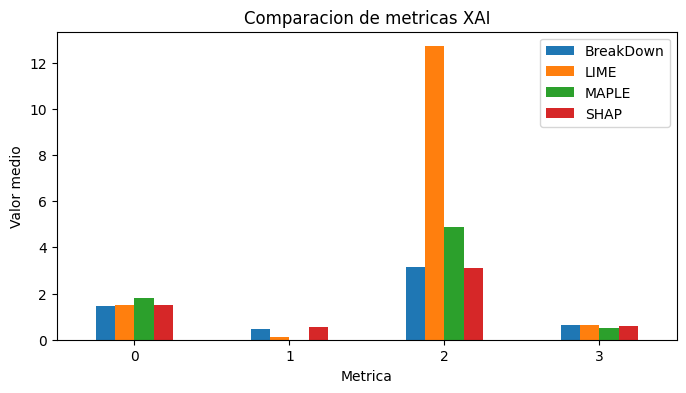

In [17]:
ax = comparison.plot.bar(figsize=(8, 4))
ax.set_title("Comparacion de metricas XAI")
ax.set_xlabel("Metrica")
ax.set_ylabel("Valor medio")
ax.tick_params(axis="x", rotation=0)